<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 9.1: NN with Keras
INSTRUCTIONS:
- Read the guides and hints, then create the necessary analysis and code to find an answer and conclusion for the task below.
- **NOTE**: This is a Regression problem. Consider the appropriate:
    - Activation function
    - Loss/Cost Function
    - Metrics

### Import libraries

In [34]:
!pip install tensorflow

  Using cached protobuf-5.29.5-cp38-abi3-macosx_10_9_universal2.whl.metadata (592 bytes)
Using cached protobuf-5.29.5-cp38-abi3-macosx_10_9_universal2.whl (418 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.73.0 requires protobuf<7.0.0,>=6.30.0, but you have protobuf 5.29.5 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [127]:
from sklearn import datasets
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input

from sklearn.metrics import r2_score

### Load data
Load the Diabetes dataset from **SciKit-Learn**.

In [38]:
diabetes = datasets.load_diabetes()
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### Prepare input data

In [40]:
X = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [51]:
n_cols = X.shape[1]
n_cols

10

### Split the data (training/test)

In [84]:
y = diabetes.target
y[:10]

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310.])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 1)

### Create the model's architecture

In [21]:
model = Sequential()

In [54]:
# Add the first hidden layer
model.add(Dense(48, activation = 'relu', input_shape = (n_cols, )))
# Add the second hidden layer
model.add(Dense(24, activation = 'relu'))

# Add the output layer
model.add(Dense(1, activation = 'linear')) #default is linear in Keras so this is the same as Dense(1)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 48)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,729 (6.75 KB)

 Non-trainable params: 0 (0.00 B)

None


### Compile the model

In [65]:
model.compile(
    optimizer = 'adam', #default go-to for most problems
    loss = 'mse', #mse for regression problem with real number output
    metrics = ['mse']) #mse punishes large errors

### Fit the training data

In [74]:
%%time
history = model.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    batch_size = 16, #batch size recommended to be powers of 2 because modern GPUs and TPUs process data in blocks of 2^n
    epochs = 50,
    verbose = 1)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 31158.5117 - mse: 31158.5117 - val_loss: 32809.9883 - val_mse: 32809.9883
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 27907.1777 - mse: 27907.1777 - val_loss: 32761.7246 - val_mse: 32761.7246
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28995.3555 - mse: 28995.3555 - val_loss: 32683.7695 - val_mse: 32683.7695
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27586.0312 - mse: 27586.0312 - val_loss: 32550.0195 - val_mse: 32550.0195
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27808.0645 - mse: 27808.0645 - val_loss: 32334.8574 - val_mse: 32334.8574
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29265.7695 - mse: 29265.7695 - val_loss: 32002.2305 - val_mse: 32002.2305
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25683.7715 - mse: 25683.7715 - val_loss: 31527.1484 - val_mse: 31527.1484
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 28915.5469 - mse: 

### Create predictions

In [79]:
predictions = model.predict(X_test)
predictions

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[125.15366 ],
       [ 91.24358 ],
       [160.40288 ],
       [ 80.83793 ],
       [184.10463 ],
       [184.2762  ],
       [209.72734 ],
       [148.63309 ],
       [157.60185 ],
       [133.37502 ],
       [174.70454 ],
       [187.6123  ],
       [119.96076 ],
       [ 92.23452 ],
       [191.83797 ],
       [181.69115 ],
       [179.00404 ],
       [109.54954 ],
       [168.30263 ],
       [171.3567  ],
       [194.14165 ],
       [103.17347 ],
       [128.2123  ],
       [ 86.708885],
       [ 97.25637 ],
       [178.22118 ],
       [ 97.604774],
       [150.67877 ],
       [164.59192 ],
       [189.66139 ],
       [175.5475  ],
       [156.07796 ],
       [173.09766 ],
       [ 95.58104 ],
       [142.23    ],
       [193.84036 ],
       [ 97.62278 ],
       [204.51497 ],
       [178.64442 ],
       [183.00128 ],
       [152.03268 ],
       [168.88759 ],
       [137.55803 ],
       [142.79573 ],
       [134.99513 ],
       [197.10022 ],
       [129.82089 ],
       [134.1

### Evaluate the model

In [104]:
score = model.evaluate(X_test, y_test)
score

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3189.1321 - mse: 3189.1321 


[3230.83447265625, 3230.83447265625]

In [114]:
rmse = score[0] ** (1/2)
rmse

56.84042991266208

In [116]:
#Predictions deviate from actual by approx. 57 units on average

### Visualisation of cost

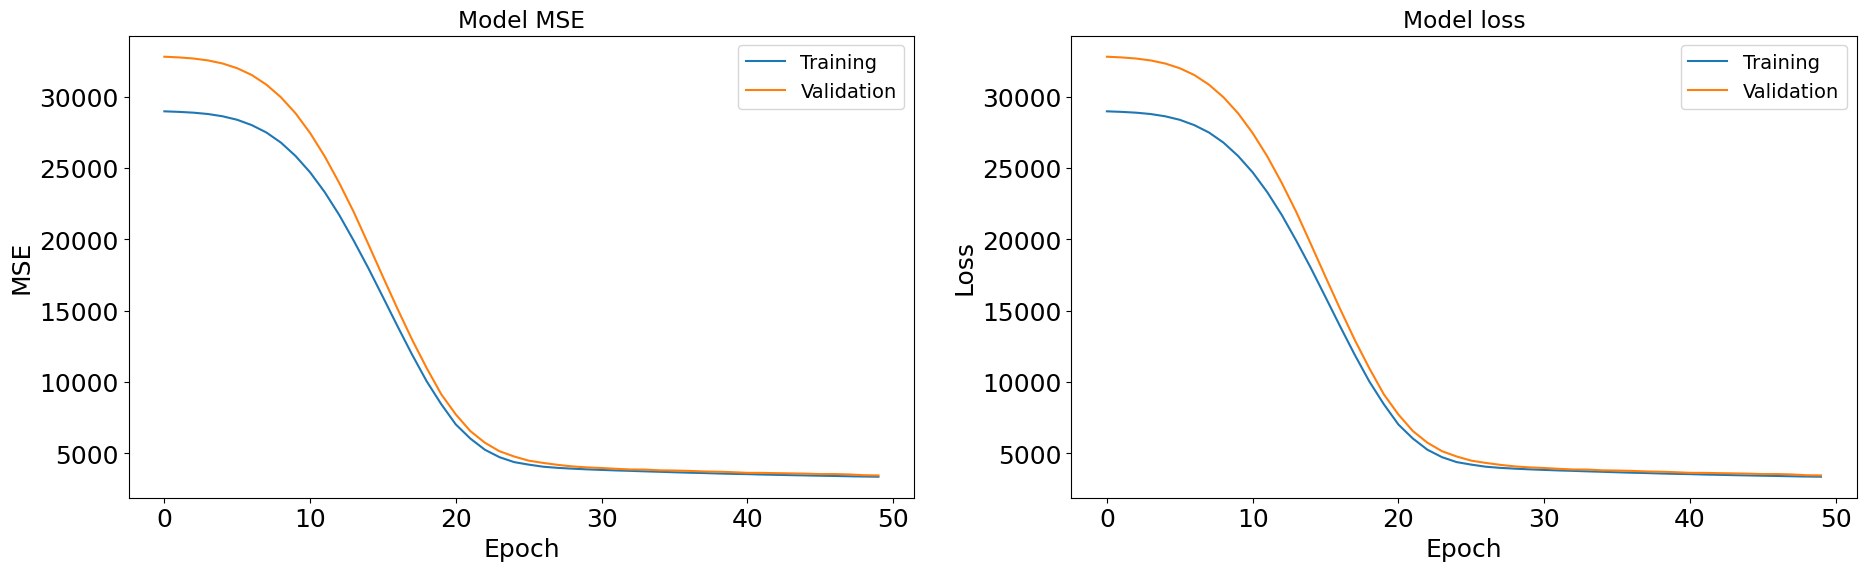

In [108]:
fig, ax = plt.subplots(1, 2, figsize = (18, 6))
fig.subplots_adjust(left = 0.02, right = 0.98, wspace = 0.2)

plt.rcParams.update({'font.size': 14})

# Plot training & validation accuracy values
ax[0].plot(history.history['mse'], label = 'Training')
ax[0].plot(history.history['val_mse'], label = 'Validation')
ax[0].set_title('Model MSE')
ax[0].set_ylabel('MSE')
ax[0].set_xlabel('Epoch')
ax[0].legend()

# Plot training & validation loss values
ax[1].plot(history.history['loss'], label = 'Training')
ax[1].plot(history.history['val_loss'], label = 'Validation')
ax[1].set_title('Model loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.show()

Interpretation:
- Model performs well and stagnates after 25 epochs
- Training and validation curves are close together so there is no overfitting

### Visualisation of residuals

In [131]:
# Calculate R2 and adjusted R2
r2 = r2_score(y_test, predictions)
n, p = X.shape # sample size, number of explanatory variables
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\:'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\:'
/var/folders/sp/g7sxk3ks3l53htnh17p_16sw0000gn/T/ipykernel_45464/813702209.py:8: SyntaxWarning: invalid escape sequence '\p'
  plt.hlines(d_mean + d_std, 0, n_pred, 'r', lw = 1, label = '$\pm \: std$')
/var/folders/sp/g7sxk3ks3l53htnh17p_16sw0000gn/T/ipykernel_45464/813702209.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$\hat y - y$')
/var/folders/sp/g7sxk3ks3l53htnh17p_16sw0000gn/T/ipykernel_45464/813702209.py:15: SyntaxWarning: invalid escape sequence '\:'
  '$R^2: %.2f, \: Adjusted \: R^2: %.2f$' % (r2, adjusted_r2),


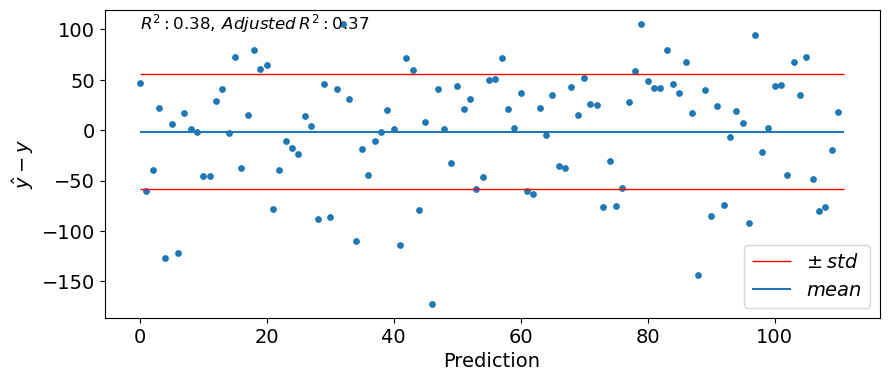

In [140]:
#Create residual plot
difference = predictions.flatten() - y_test
d_mean = difference.mean()
d_std = difference.std()
n_pred = len(predictions)
plt.figure(figsize = (10, 4))
plt.scatter(range(n_pred), difference, s = 15)
plt.hlines(d_mean + d_std, 0, n_pred, 'r', lw = 1, label = '$\pm \: std$')
plt.hlines(d_mean, 0, n_pred, label = '$mean$')
plt.hlines(d_mean - d_std, 0, n_pred, 'r', lw = 1)
plt.xlabel('Prediction')
plt.ylabel('$\hat y - y$')
plt.legend()
plt.text(0, difference.max() * 0.95,
         '$R^2: %.2f, \: Adjusted \: R^2: %.2f$' % (r2, adjusted_r2),
         fontsize = 12)
plt.show()

Interpretation:
- Plots are randomly scattered which means the model did a good job of capturing the direction and slope of the relationship
- Plots are scattered on either side of y = 0 which means the model is unbiased
- Plots are mostly within one std of y = 0 which means most plots have a low error but there are few outliers with very high errors
- R2 of 0.38 means the model explains only 38% of the variability in the data, suggesting there are other factors that are not included in the model



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



